In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [6]:
original_path = r"F:\work\python\archive\classification_task\train\no_tumor"

# highlighted = ["brisc2025_train_02486_no_ax_t1.jpg", "brisc2025_train_02493_no_ax_t1.jpg", "brisc2025_train_02494_no_ax_t1.jpg", "brisc2025_train_02528_no_ax_t1.jpg", "brisc2025_train_02532_no_ax_t1.jpg"]
# normal = ["brisc2025_train_02483_no_ax_t1.jpg", "brisc2025_train_02484_no_ax_t1.jpg", "brisc2025_train_02485_no_ax_t1.jpg", "brisc2025_train_02489_no_ax_t1.jpg", "brisc2025_train_02492_no_ax_t1.jpg"]


highlighted = ["brisc2025_train_02486_no_ax_t1.jpg", "brisc2025_train_02493_no_ax_t1.jpg"]
normal = ["brisc2025_train_02483_no_ax_t1.jpg", "brisc2025_train_02484_no_ax_t1.jpg"]


In [9]:
def plot_histograms(image_list, title):

    for img_name in image_list:

        img_path = os.path.join(original_path, img_name)
        image = cv2.imread(img_path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        print(f"\nImage: {img_name}")
        print("Mean:", np.mean(gray))
        print("Std:", np.std(gray))
        print("Max:", np.max(gray))

        plt.figure(figsize=(6,4))
        plt.hist(gray.ravel(), bins=256)
        plt.title(f"{title} - {img_name}")
        plt.xlabel("Pixel Intensity (0-255)")
        plt.ylabel("Frequency")
        plt.show()



Image: brisc2025_train_02486_no_ax_t1.jpg
Mean: 39.59592994078089
Std: 51.89979561617186
Max: 245


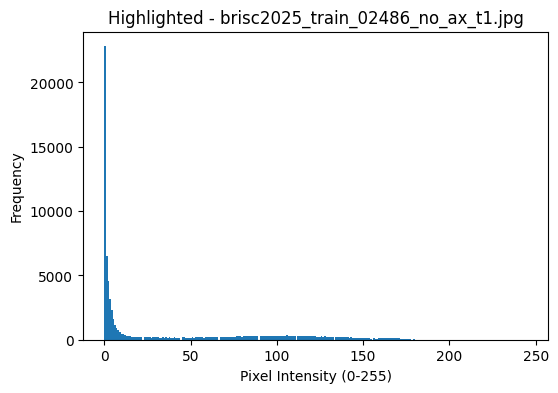


Image: brisc2025_train_02493_no_ax_t1.jpg
Mean: 54.178598313760915
Std: 58.952770469272735
Max: 242


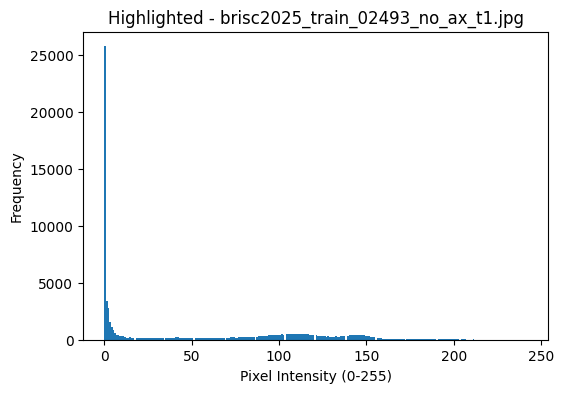


Image: brisc2025_train_02483_no_ax_t1.jpg
Mean: 31.10173893405601
Std: 42.354239005863754
Max: 217


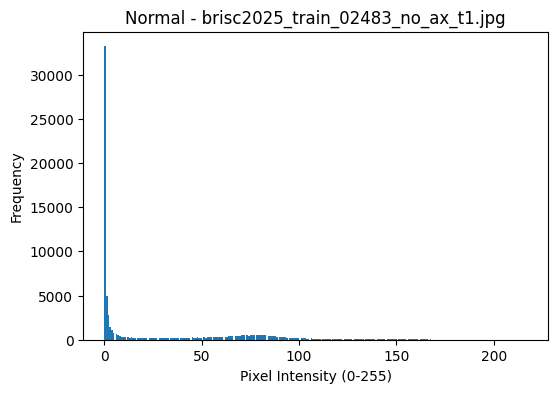


Image: brisc2025_train_02484_no_ax_t1.jpg
Mean: 37.368300210779886
Std: 48.34357733742499
Max: 243


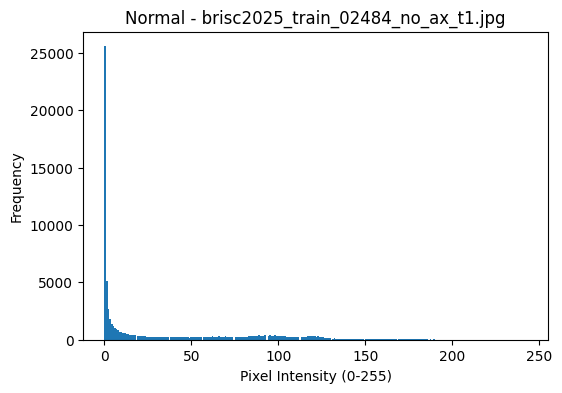

In [10]:
# Highlighted images
plot_histograms(highlighted, "Highlighted")

# Normal images
plot_histograms(normal, "Normal")

C:\Users\gopik\AppData\Local\Temp\ipykernel_18588\230548787.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([highlighted_pixels, normal_pixels], labels=["Highlighted", "Normal"])


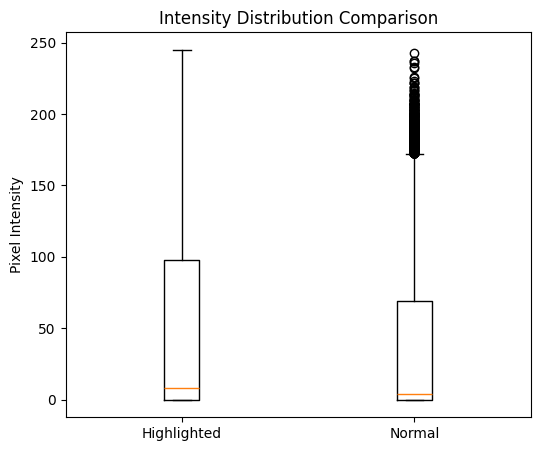

In [11]:
# Boxplot
def collect_intensity(image_list):
    all_pixels = []
    for img_name in image_list:
        img = cv2.imread(os.path.join(original_path, img_name))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        all_pixels.extend(gray.ravel())
    return all_pixels

highlighted_pixels = collect_intensity(highlighted)
normal_pixels = collect_intensity(normal)

plt.figure(figsize=(6,5))
plt.boxplot([highlighted_pixels, normal_pixels], labels=["Highlighted", "Normal"])
plt.ylabel("Pixel Intensity")
plt.title("Intensity Distribution Comparison")
plt.show()

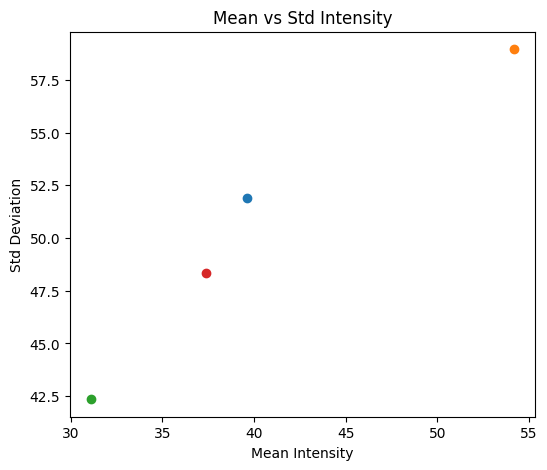

In [12]:
# Mean vs Standard Deviation Scatter Plot

means = []
stds = []
labels = []

for img_list, label in [(highlighted, "H"), (normal, "N")]:
    for img_name in img_list:
        img = cv2.imread(os.path.join(original_path, img_name))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        means.append(np.mean(gray))
        stds.append(np.std(gray))
        labels.append(label)

plt.figure(figsize=(6,5))

for i in range(len(means)):
    if labels[i] == "H":
        plt.scatter(means[i], stds[i])
    else:
        plt.scatter(means[i], stds[i])

plt.xlabel("Mean Intensity")
plt.ylabel("Std Deviation")
plt.title("Mean vs Std Intensity")
plt.show()

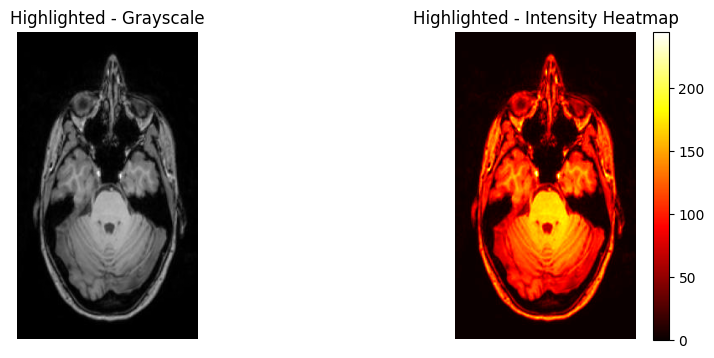

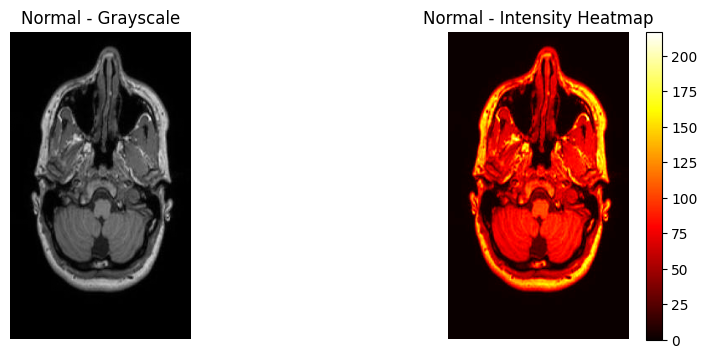

In [ ]:
# Heatmap of Intensity
highlighted_img = "brisc2025_train_02486_no_ax_t1.jpg"
normal_img = "brisc2025_train_02483_no_ax_t1.jpg"

def show_comparison(img_name, label):

    img_path = os.path.join(original_path, img_name)
    image = cv2.imread(img_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(10,4))

    # Original grayscale
    plt.subplot(1,2,1)
    plt.imshow(gray, cmap="gray")
    plt.title(f"{label} - Grayscale")
    plt.axis("off")

    # Heatmap
    plt.subplot(1,2,2)
    plt.imshow(gray, cmap="")
    plt.title(f"{label} - Intensity Heatmap")
    plt.colorbar()
    plt.axis("off")

    plt.show()


# Show highlighted image
show_comparison(highlighted_img, "Highlighted")

# Show normal image
show_comparison(normal_img, "Normal")

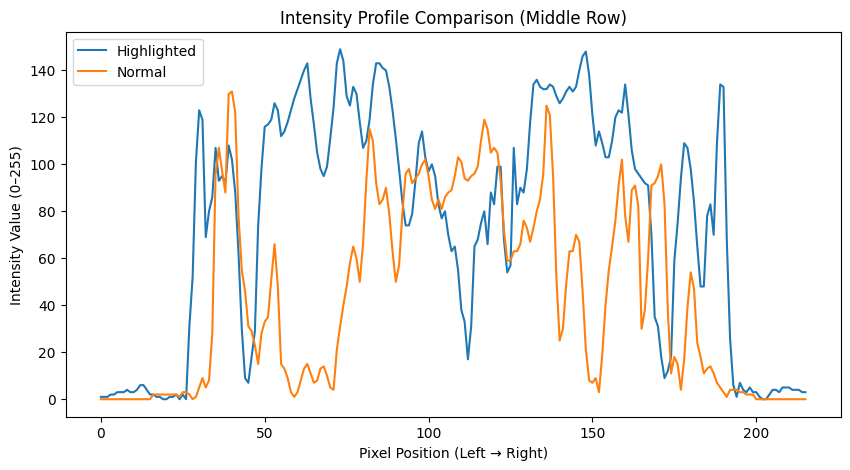

In [20]:
# Intensity Profile

def intensity_profile(img_name, label):

    img_path = os.path.join(original_path, img_name)
    image = cv2.imread(img_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Take middle horizontal row
    middle_row = gray[gray.shape[0] // 2, :]

    return middle_row


# Get profiles
profile_highlighted = intensity_profile(highlighted_img, "Highlighted")
profile_normal = intensity_profile(normal_img, "Normal")

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(profile_highlighted, label="Highlighted")
plt.plot(profile_normal, label="Normal")
plt.xlabel("Pixel Position (Left → Right)")
plt.ylabel("Intensity Value (0–255)")
plt.title("Intensity Profile Comparison (Middle Row)")
plt.legend()
plt.show()


Image: brisc2025_train_00029_gl_ax_t1.jpg
Mean: 28.361797332763672
Std: 40.04375320539674
Max: 255
Bright Pixel Ratio: 0.005146026611328125


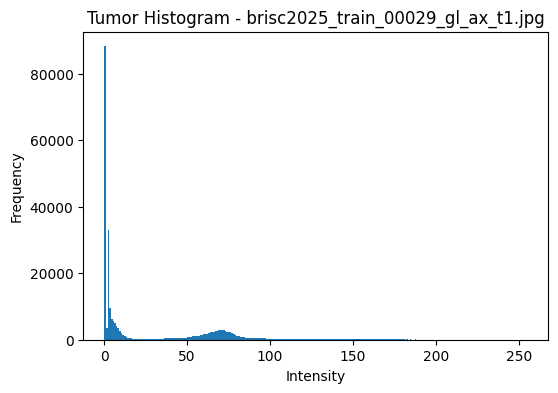

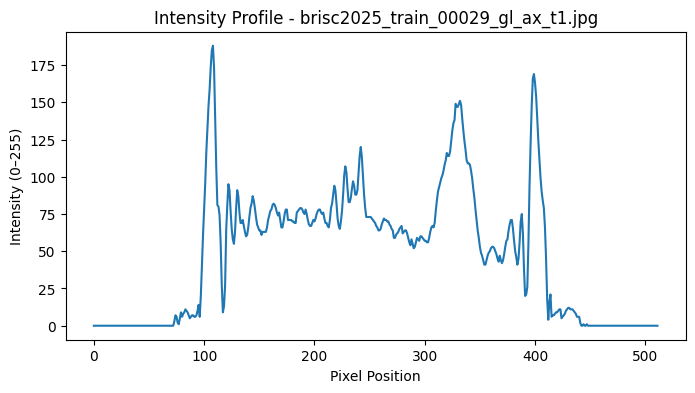


Image: brisc2025_train_00007_gl_ax_t1.jpg
Mean: 31.276996612548828
Std: 41.88561009350004
Max: 254
Bright Pixel Ratio: 0.005176544189453125


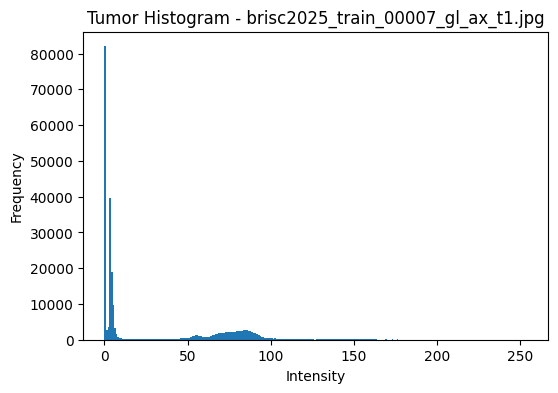

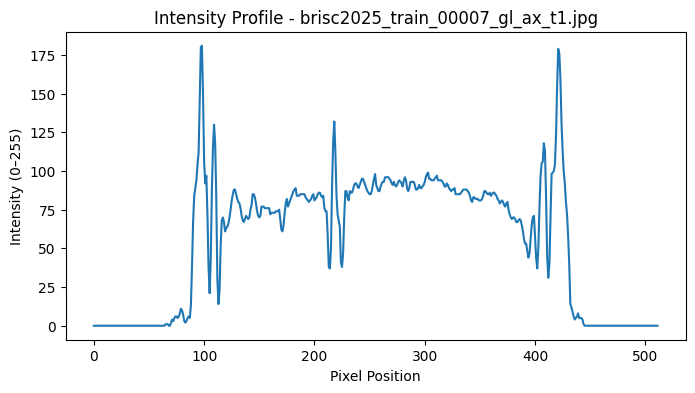

In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

tumor_path = r"F:\work\python\archive\classification_task\train\glioma"

tumor_images = ["brisc2025_train_00029_gl_ax_t1.jpg","brisc2025_train_00007_gl_ax_t1.jpg"]

def analyze_tumor(images):

    for img_name in images:

        img_path = os.path.join(tumor_path, img_name)
        image = cv2.imread(img_path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        mean_val = np.mean(gray)
        std_val = np.std(gray)
        max_val = np.max(gray)

        print(f"\nImage: {img_name}")
        print("Mean:", mean_val)
        print("Std:", std_val)
        print("Max:", max_val)

        # Bright pixel ratio
        bright_ratio = np.sum(gray > 180) / gray.size
        print("Bright Pixel Ratio:", bright_ratio)

        # 🔹 Histogram
        plt.figure(figsize=(6,4))
        plt.hist(gray.ravel(), bins=256)
        plt.title(f"Tumor Histogram - {img_name}")
        plt.xlabel("Intensity")
        plt.ylabel("Frequency")
        plt.show()

        # 🔹 Intensity Profile (Middle Row)
        middle_row = gray[gray.shape[0] // 2, :]

        plt.figure(figsize=(8,4))
        plt.plot(middle_row)
        plt.title(f"Intensity Profile - {img_name}")
        plt.xlabel("Pixel Position")
        plt.ylabel("Intensity (0–255)")
        plt.show()

analyze_tumor(tumor_images)

In [32]:
tumor_path = r"F:\work\python\archive\classification_task\train\glioma"
notumor_path = r"F:\work\python\archive\classification_task\train\no_tumor"

In [33]:
tumor_image = "brisc2025_train_00029_gl_ax_t1.jpg"   # replace with real tumor file
notumor_image = "brisc2025_train_02494_no_ax_t1.jpg"

In [34]:
print(os.listdir(tumor_path)[:5])
print(os.listdir(notumor_path)[:5])

['brisc2025_train_00001_gl_ax_t1.jpg', 'brisc2025_train_00002_gl_ax_t1.jpg', 'brisc2025_train_00003_gl_ax_t1.jpg', 'brisc2025_train_00004_gl_ax_t1.jpg', 'brisc2025_train_00005_gl_ax_t1.jpg']
['brisc2025_train_02477_no_ax_t1.jpg', 'brisc2025_train_02478_no_ax_t1.jpg', 'brisc2025_train_02479_no_ax_t1.jpg', 'brisc2025_train_02480_no_ax_t1.jpg', 'brisc2025_train_02481_no_ax_t1.jpg']


In [35]:
def average_profile(folder_path, image_name):
    img_path = os.path.join(folder_path, image_name)
    img = cv2.imread(img_path)

    if img is None:
        print("Could not load:", img_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray, axis=0)

In [36]:
tumor_profile = average_profile(tumor_path, tumor_image)
notumor_profile = average_profile(notumor_path, notumor_image)

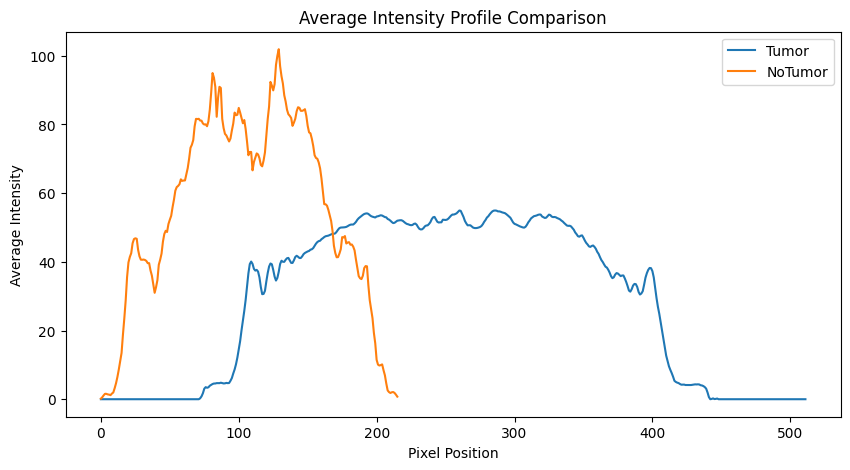

In [37]:
plt.figure(figsize=(10,5))
plt.plot(tumor_profile, label="Tumor")
plt.plot(notumor_profile, label="NoTumor")
plt.legend()
plt.title("Average Intensity Profile Comparison")
plt.xlabel("Pixel Position")
plt.ylabel("Average Intensity")
plt.show()